In [4]:
import numpy as np
import glob
import struct
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter, welch

In [5]:
FS = 2_000_000
DATA_PATH = r"C:\Users\HP\Downloads\data\data\*.txt"
MAX_SAMPLES = 300000

In [ ]:
# Here we Read hex IQ samples from file and convert them into complex numbers
# Complex representation (I + jQ) preserves amplitude and phase of the RF signal.

In [6]:
# IQ READER
def read_iq_stream(fname, max_samples):

    import numpy as np
    import struct
    import re

    I = []
    Q = []

    with open(fname) as f:

        for line in f:

            if len(I) >= max_samples:
                break

            
            vals = re.findall(r'[0-9A-Fa-f]{8}', line)

            if len(vals) < 2:
                continue

            try:
                I.append(struct.unpack(">f", bytes.fromhex(vals[0]))[0])
                Q.append(struct.unpack(">f", bytes.fromhex(vals[1]))[0])
            except:
                continue

    return np.array(I) + 1j*np.array(Q)



In [8]:
# LOAD FILE
files = sorted(glob.glob(DATA_PATH))

print("Total files:",len(files))

f = files[20]   
print("Testing file:",f)

iq = read_iq_stream(f,MAX_SAMPLES)

print("Samples loaded:",len(iq))

Total files: 300
Testing file: C:\Users\HP\Downloads\data\data\dsn_capture_1772525563.txt
Samples loaded: 300000


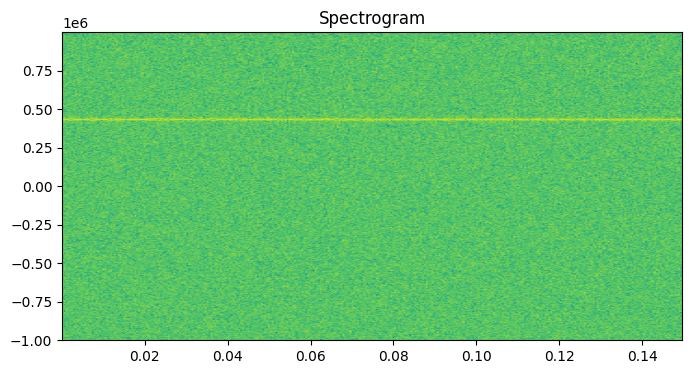

In [9]:
# SPECTROGRAM
plt.figure(figsize=(8,4))
plt.specgram(iq, NFFT=1024, Fs=FS)
plt.title("Spectrogram")
plt.show()

In [ ]:
# We used FFT to estimate the dominant carrier frequency of the received signal
# The peak in the spectrum corresponds to the carrier offset.

In [10]:
# CARRIER DETECTION
spectrum = np.fft.fftshift(np.fft.fft(iq))
freqs = np.fft.fftshift(np.fft.fftfreq(len(iq),1/FS))
power = np.abs(spectrum)**2
carrier = freqs[np.argmax(np.abs(spectrum))]
print("Detected Carrier (Hz):",carrier)

Detected Carrier (Hz): 429546.6666666667


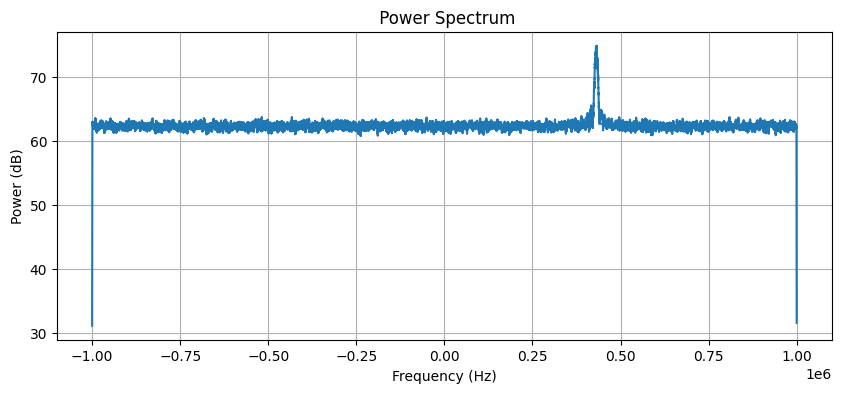

In [76]:
power_db = 10*np.log10(power)

window = 200
power_smooth = np.convolve(power_db, np.ones(window)/window, mode='same')

plt.figure(figsize=(10,4))
plt.plot(freqs, power_smooth)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.title(" Power Spectrum")
plt.grid()
plt.show()

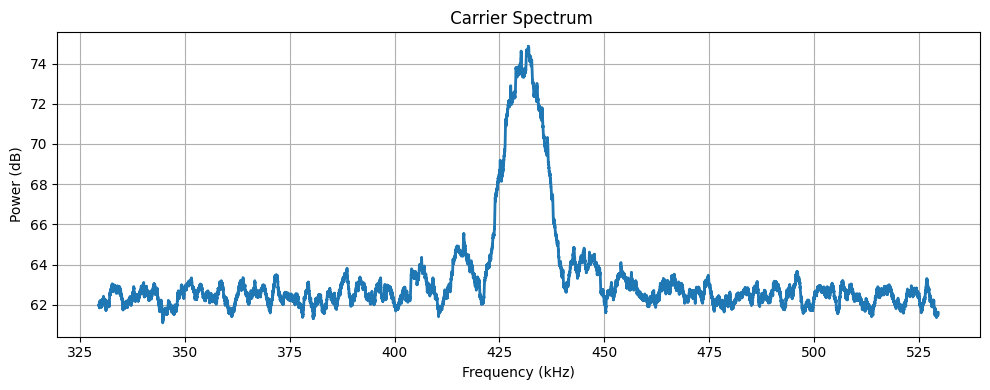

In [77]:

power_db = 10*np.log10(power + 1e-12)

window = 200
power_smooth = np.convolve(power_db, np.ones(window)/window, mode='same')

zoom = 100000  

mask = (freqs > carrier-zoom) & (freqs < carrier+zoom)

plt.figure(figsize=(10,4))

plt.plot(freqs[mask]/1e3, power_smooth[mask], linewidth=2)

plt.title(" Carrier Spectrum")
plt.xlabel("Frequency (kHz)")
plt.ylabel("Power (dB)")
plt.grid(True)

plt.tight_layout()
plt.show()

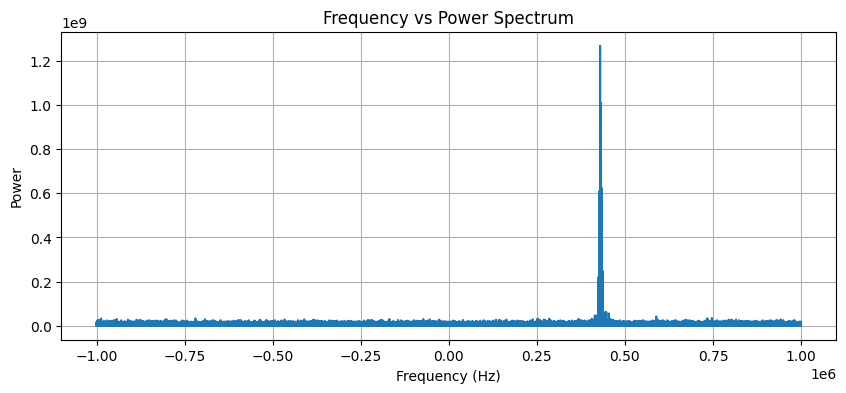

In [14]:
plt.figure(figsize=(10,4))
plt.plot(freqs, power)
plt.title("Frequency vs Power Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.grid()
plt.show()

In [ ]:
# Shift the signal to baseband by removing the carrier frequency
# This simplifies demodulation since the signal is now centered around 0 Hz

In [78]:
# Lowpass
def lowpass(sig,cutoff):

    b,a = butter(5,cutoff/(FS/2))
    return lfilter(b,a,sig)


In [15]:
# BASEBAND
t = np.arange(len(iq))/FS
baseband = iq*np.exp(-1j*2*np.pi*carrier*t)

filtered = lowpass(baseband,50000)


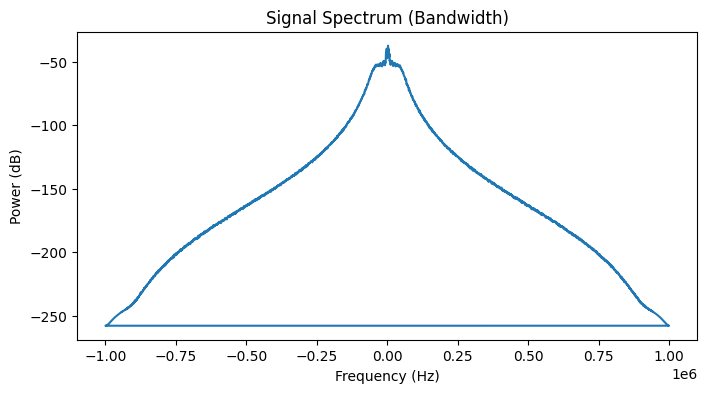

In [16]:
# SPECTRUM
f_spec,P = welch(filtered,FS,nperseg=4096)

plt.figure(figsize=(8,4))
plt.plot(f_spec,10*np.log10(P))
plt.title("Signal Spectrum (Bandwidth)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB)")
plt.show()


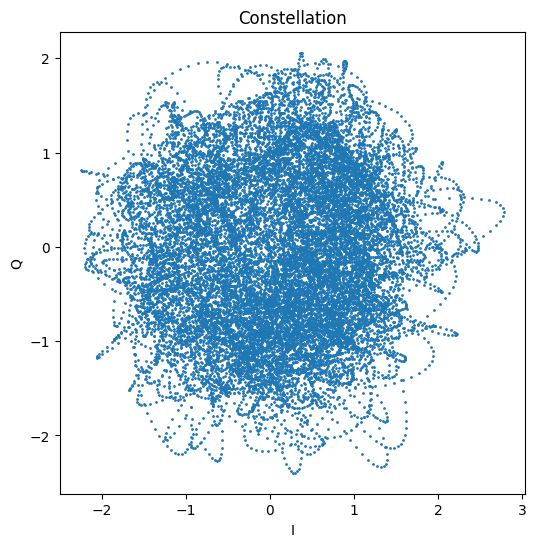

In [17]:
# Constellation
plt.figure(figsize=(6,6))
plt.scatter(np.real(filtered[:20000]), np.imag(filtered[:20000]), s=1)
plt.xlabel("I")
plt.ylabel("Q")
plt.title("Constellation")
plt.show()

In [ ]:
# Costas loop is used for carrier phase recovery.
# It continuously adjusts the signal phase to align constellation points according to the given constraints(doppler shift and phase mismatch)

In [18]:
#costas loop

def costas_loop(signal):

    phase = 0
    freq = 0

    alpha = 0.01
    beta = 0.0001

    out = []

    for s in signal:

        corrected = s*np.exp(-1j*phase)

        error = np.sign(corrected.real)*corrected.imag

        freq += beta*error
        phase += freq + alpha*error

        out.append(corrected)

    return np.array(out)

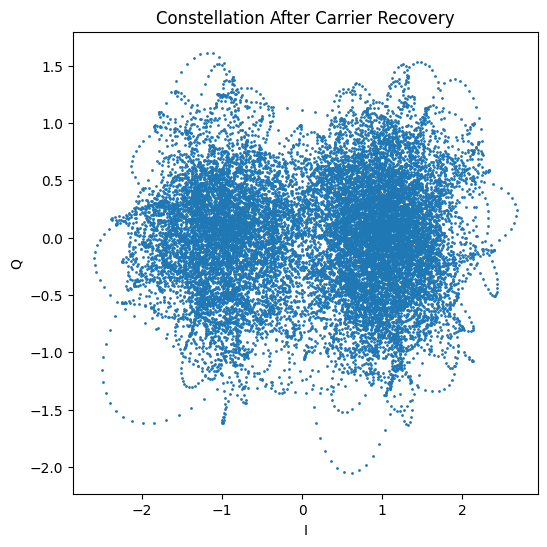

In [19]:
tracked = costas_loop(filtered)

plt.figure(figsize=(6,6))
plt.scatter(np.real(tracked[:20000]), np.imag(tracked[:20000]), s=1)
plt.title("Constellation After Carrier Recovery")
plt.xlabel("I")
plt.ylabel("Q")
plt.show()

In [20]:
tracked = tracked[:50000]

In [ ]:
# We estimated symbol period using autocorrelation
# This determines how many samples correspond to one transmitted symbol

In [21]:
import numpy as np
import matplotlib.pyplot as plt

env = np.abs(tracked)

env = env - np.mean(env)

corr = np.correlate(env, env, mode='full')
corr = corr[len(corr)//2:]

corr = corr / np.max(np.abs(corr))

lags = np.arange(len(corr))
times = lags / FS

search = corr[int(FS/50000):int(FS/2000)]

peak = np.argmax(search)

symbol_period = (peak + int(FS/50000)) / FS

symbol_rate = 1 / symbol_period

print("Estimated Symbol Rate:", symbol_rate)

Estimated Symbol Rate: 40816.32653061225


In [40]:
print("symbol period : ",symbol_period)

symbol period :  2.45e-05


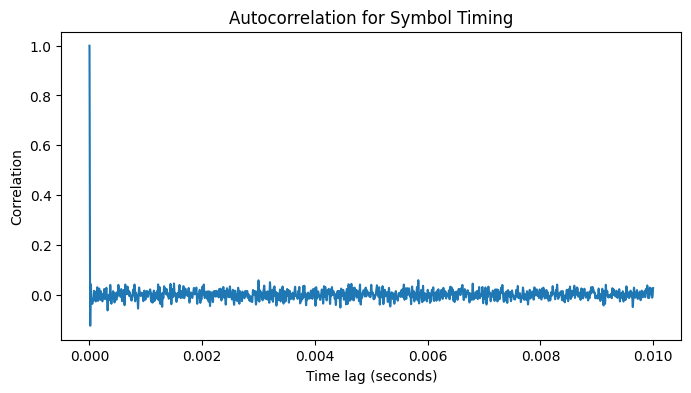

In [23]:
plt.figure(figsize=(8,4))
plt.plot(times[:20000], corr[:20000])
plt.title("Autocorrelation for Symbol Timing")
plt.xlabel("Time lag (seconds)")
plt.ylabel("Correlation")
plt.show()

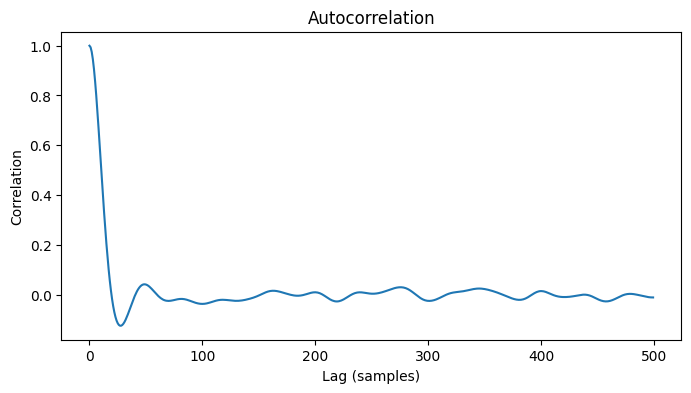

In [24]:
plt.figure(figsize=(8,4))
plt.plot(corr[:500])
plt.title("Autocorrelation")
plt.xlabel("Lag (samples)")
plt.ylabel("Correlation")
plt.show()

In [27]:
sr = int(symbol_rate)
sps = int(FS / sr)

print("Samples per symbol:", sps)

Samples per symbol: 49


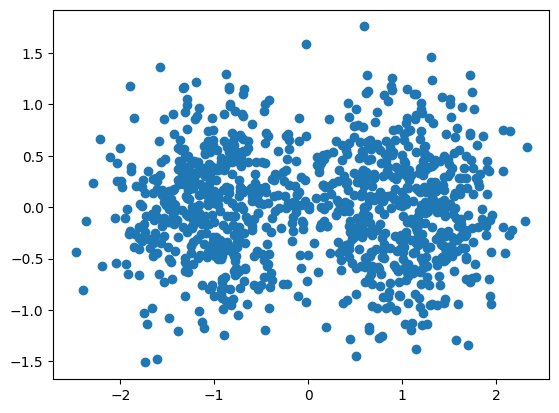

In [28]:
symbols = tracked[::49]
plt.scatter(symbols.real,symbols.imag)
plt.show()

Best timing offset: 46


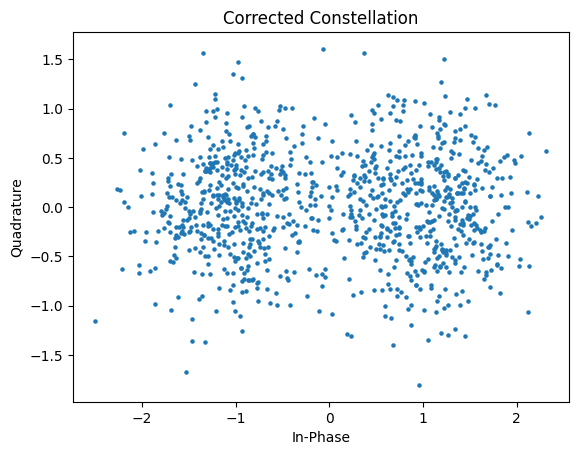

In [29]:
import numpy as np
import matplotlib.pyplot as plt

best_offset = 0
best_metric = 0

for offset in range(sps):   # sps = 49

    symbols = tracked[offset::sps]

    metric = np.mean(np.abs(symbols))

    if metric > best_metric:
        best_metric = metric
        best_offset = offset

print("Best timing offset:", best_offset)

symbols = tracked[best_offset::sps]

plt.scatter(symbols.real, symbols.imag, s=5)
plt.title("Corrected Constellation")
plt.xlabel("In-Phase")
plt.ylabel("Quadrature")
plt.show()

In [ ]:
# Using standard BPSK decision rule:
# positive real value -> bit 1
# negative real value -> bit 0

In [30]:
# Bpsk demodulation
bits = (np.real(symbols) > 0).astype(int)

In [ ]:
# Search for CCSDS synchronization word (0x1ACFFC1D)
# This pattern marks the beginning of a telemetry packet

In [48]:
# CCSDS SYNC WORD
sync_hex = 0x1ACFFC1D
sync_bits = np.array([int(b) for b in format(sync_hex,"032b")])

diff_bits = np.mod(np.diff(bits),2)

streams = [bits,1-bits,diff_bits,1-diff_bits]



for data in streams:

    corr = np.correlate(data*2-1,sync_bits*2-1,mode="valid")

    print("Max correlation:",np.max(corr))

    sync_positions = np.where(corr > 18)[0]
    print(sync_positions)

    idx = np.argmax(corr)

    if corr[idx] > 20:

        print("\nSYNC FOUND")
        print("Bit index:",idx)
        break

Max correlation: 20
[197]
Max correlation: 18
[]
Max correlation: 14
[]
Max correlation: 16
[]


In [32]:
print(len(bits))


1020


In [ ]:
# CCSDS primary header is 6 bytes (48 bits)
# Remaining bytes correspond to the telemetry payload

In [73]:
corr = np.correlate(bits*2-1, sync_bits*2-1, mode="valid")

sync_positions = np.where(corr > 18)[0]

print(sync_positions)

print("Total packets detected:", len(sync_positions))

packet_number = 1

for start in sync_positions:

    packet = bits[start:start+1024]

    byte_vals = []

    for i in range(0, len(packet), 8):

        byte = packet[i:i+8]

        if len(byte) < 8:
            break

        val = int("".join(map(str, byte)), 2)

        byte_vals.append(val)

    header = byte_vals[:6]
    payload = byte_vals
    telemetry_payload = byte_vals[6:]

    print("\n----------------------------------")
    print("Packet", packet_number)
    print("Bit position:", start)
    
    print("Header:", header)
    print("")
    print("Payload",payload)
    print(" ")
    print("Telemetry Payload :", telemetry_payload)

    packet_number += 1

[197]
Total packets detected: 1

----------------------------------
Packet 1
Bit position: 197
Header: [3, 255, 252, 31, 254, 30]

Payload [3, 255, 252, 31, 254, 30, 254, 31, 255, 240, 15, 15, 191, 15, 255, 7, 255, 216, 7, 135, 255, 128, 3, 203, 255, 255, 255, 193, 246, 1, 225, 224, 0, 30, 31, 240, 254, 240, 240, 240, 0, 127, 135, 248, 8, 120, 7, 252, 3, 192, 0, 60, 3, 255, 255, 254, 0, 0, 31, 255, 15, 255, 15, 255, 5, 255, 135, 143, 128, 0, 127, 255, 192, 0, 63, 255, 192, 0, 0, 5, 224, 1, 224, 1, 241, 255, 248, 79, 240, 127, 7, 0, 120, 124, 33, 120, 122, 124, 72, 60, 60, 63]
 
Telemetry Payload : [254, 31, 255, 240, 15, 15, 191, 15, 255, 7, 255, 216, 7, 135, 255, 128, 3, 203, 255, 255, 255, 193, 246, 1, 225, 224, 0, 30, 31, 240, 254, 240, 240, 240, 0, 127, 135, 248, 8, 120, 7, 252, 3, 192, 0, 60, 3, 255, 255, 254, 0, 0, 31, 255, 15, 255, 15, 255, 5, 255, 135, 143, 128, 0, 127, 255, 192, 0, 63, 255, 192, 0, 0, 5, 224, 1, 224, 1, 241, 255, 248, 79, 240, 127, 7, 0, 120, 124, 33, 120, 122

In [63]:
print("Payload length is : ",len(payload))

Payload length is :  96


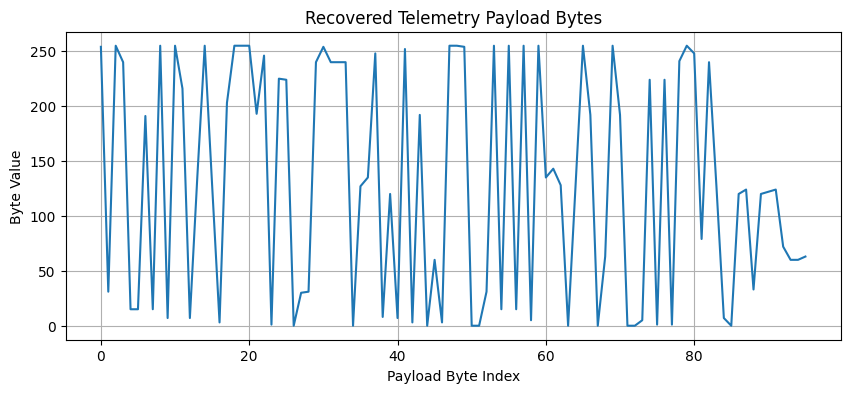

Min: 0
Max: 255
Mean: 129.72916666666666
Unique values: 35


In [67]:
plt.figure(figsize=(10,4))
plt.plot(telemetry_payload)
plt.title("Recovered Telemetry Payload Bytes")
plt.xlabel("Payload Byte Index")
plt.ylabel("Byte Value")
plt.grid(True)
plt.show()
print("Min:", np.min(telemetry_payload))
print("Max:", np.max(telemetry_payload))
print("Mean:", np.mean(telemetry_payload))

unique_vals = len(set(telemetry_payload))
print("Unique values:", unique_vals)

In [ ]:
# We combined consecutive bytes to form 16-bit telemetry values
# These represent sensor or system data transmitted by the spacecraft Voyager X

 telemetry values are :  [65055, 65520, 3855, 48911, 65287, 65496, 1927, 65408, 971, 65535, 65473, 62977, 57824, 30, 8176, 65264, 61680, 127, 34808, 2168, 2044, 960, 60, 1023, 65534, 0, 8191, 4095, 4095, 1535, 34703, 32768, 32767, 49152, 16383, 49152, 5, 57345, 57345, 61951, 63567, 61567, 1792, 30844, 8568, 31356, 18492, 15423]


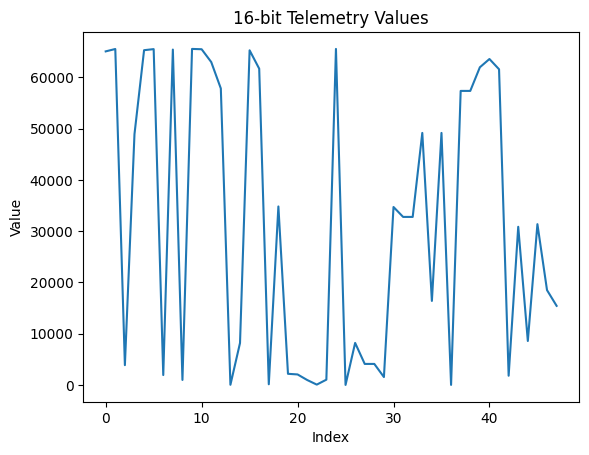

In [74]:
telemetry = []

for i in range(0, len(telemetry_payload)-1, 2):
    val = telemetry_payload[i] << 8 | telemetry_payload[i+1]
    telemetry.append(val)

print(" telemetry values are : ",telemetry)

plt.figure()
plt.plot(telemetry)
plt.title("16-bit Telemetry Values")
plt.xlabel("Index")
plt.ylabel("Value")
plt.show()


In [75]:
print(len(telemetry))

48


In [ ]:
#END